# 3d visualization for ODE models

2026-02-22 Starting point for Sara, Fiona, and Duru's project. This code does time integration
of an ODE model of plane Couette flow and produces 3d visualizations of the results as PNG files
at intervals $\Delta t = 1$.

### 1. load some code

In [6]:
using LinearAlgebra, Polynomials, DelimitedFiles, BenchmarkTools
import JLD2 as jld
using Revise
using CloudAtlas

includet("Utilities.jl")
includet("flowfield3d.jl")

Makie.inline!(true)

sx, sy, sz, tx, tz = halfbox_symmetries()
pwd()

"c:\\Users\\cbalusek\\Desktop\\CloudAtlas\\notebooks"

### 2. Build an ODE model of plane Couette flow

The basic idea of the model is to approximate the fluid velocity field $u(\chi,t)$ with the sum
\begin{align*} 
    u(\chi,t) = \sum_{i=1}^{m} x_i(t) \Psi_i(\chi)
\end{align*}
Here $\chi$ is the vector of spatial coordinates $\chi = (x,y,z)$ for the fluid, 
and $\Psi_(\chi)$ are expansion functions, or basis elements, that vary over $\chi$.
The variation of the fluid veclocity in time is represented by changing values of the 
coefficients $x_i(t)$. 
    
    
The model is an ordinary differential equation of form
\begin{align*}
  B \frac{dx}{dt} = A x + N(x,x)
\end{align*}
where $x$ is a vector of coefficients, $x = (x_1, x_2, \ldots, x_m)$. 

In [171]:
# Define a differential-equation model of plane Couette flow

J,K,L = 1,1,3                       # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
modNum = 1
eq1file = "simulated_data/x$modNum-$J-$K-$L-data.asc" #"xeq1-Re200-2-3-5.asc"    # Data file containing projection of Nagata equilibrium
xeq1data = jld.load_object(eq1file)

51×101 Matrix{Any}:
 Any[6.28319, 3.14159, 200, [0.180257, -0.0153102, 0.252804, -0.0416442, -0.0392103, -0.00653022, -0.0132838, 0.0104037, -0.0291418, -0.00594245, -0.0148798, -0.0246413, -0.0207167, -0.0381138, 0.000581285, 0.0284429, 0.0743532], Symmetry[Symmetry(-1, -1, -1, 0//1, 0//1, 1), Symmetry(1, 1, -1, 1//2, 1//2, 1)], false]   …  Any[12.5664, 3.14159, 200, [0.117205, -0.0349593, 0.201164, -0.00948269, -0.0204781, 0.00296064, -0.00596862, 0.0102209, -0.0372847, -0.010786, -0.0135079, -0.010157, -0.0103395, -0.0362611, 0.00639643, 0.0178854, 0.0390045], Symmetry[Symmetry(-1, -1, -1, 0//1, 0//1, 1), Symmetry(1, 1, -1, 1//2, 1//2, 1)], true]
 Any[6.28319, 3.20757, 200, [0.176064, -0.016557, 0.254354, -0.0395897, -0.0379563, -0.00628318, -0.0131256, 0.0102343, -0.0291217, -0.00563595, -0.0148681, -0.0248568, -0.0207093, -0.0373803, 0.000297798, 0.0285091, 0.0736136], Symmetry[Symmetry(-1, -1, -1, 0//1, 0//1, 1), Symmetry(1, 1, -1, 1//2, 1//2, 1)], false]       Any[12.5664, 3.207

In [175]:
dataPos = xeq1data[51,101]

α, γ = 2*pi/dataPos[1], 2*pi/dataPos[2]                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
R = dataPos[3]                             # Reynolds number
xeq1 = dataPos[4]
H = dataPos[5]            # Generators of a symmetry group

model = ODEModel(α, γ, J,K,L, H, normalize=true);   # Build ODE model dx/dt = f(x,R)

Ψ = model.Ψ                         # Elements of expansion basis
ijkl = model.ijkl                   # Indices of expension basis elements



@show Nmodes = length(Ψ)            # Number of basis elements (modes)
@show norm(model.f(xeq1, R))   # Evaluate dx/dt = f(x,R) for x = xeq1guess

J,K,L,m == 1,1,3,17
(2J+1)(2K+1)(2L+1) + 1 == 64
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 
Nmodes = length(Ψ) = 17
norm(model.f(xeq1, R)) = 0.00023065934889607086


0.00023065934889607086

In [18]:
xeq1

12-element Vector{Float64}:
  0.011977322988601288
 -0.0029883099587505613
  0.028743274166182664
 -0.008926471813083986
 -0.004755243440711818
  0.024860880391994054
  0.0192489143349397
  0.0008080140831225816
  0.011457280031939148
 -0.029612937173006993
 -0.008888884064705194
  0.004315648652237769

### 3. Define an algorithm for time-stepping the ODE model

This function provides a way to calculate the expansion coefficients $x$ at time $t+\Delta t$
given their values at time $t$.

In [19]:
# CNAB2 = 2nd-order semi-implicit Crank-Nicolson, Adams-Bashforth time stepping algorithm
function cnab2(x₀, odemodel, R, Δt, Nsave, Nsteps)

    A = model.A1 + (1/R)*model.A2
    N = model.N
    
    LHS_linear = odemodel.B - (Δt/2)*A
    RHS_linear = odemodel.B + (Δt/2)*A

    LHS_lu = lu(LHS_linear)
    
    xn  = x₀      # xⁿ
    Nxn1 = N(x₀)  # N(xⁿ⁻¹)
    Nxn  = N(x₀)  # N(xⁿ)

    X = zeros(length(x₀), Nsteps+1)
    t = range(0, Nsteps*Nsave*Δt, Nsteps+1)

    X[:,1] = x₀
    
    for n = 1:Nsteps
        n % 10 == 0 && print("$n ")
        for s = 1:Nsave
            Nxn1 = Nxn    # shift previous N(xⁿ) to N(xⁿ⁻¹)
            Nxn = N(xn)   # calculate N(xⁿ)
            xn = LHS_lu\(RHS_linear*xn + (3Δt/2)*Nxn - (Δt/2)*Nxn1)
        end
        X[:,n+1] = xn
    end
    t,X
end

cnab2 (generic function with 1 method)

### 4. Take 500 time steps of length $\Delta t = 1$

Now we iterate the time-stepping algorithm 500 times to see how the fluid evolves.

First make a plot of the shear rate $I$ versus $t$ and see how the flow decays
to laminar flow with $I=1$.

10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350 360 370 380 390 400 410 420 430 440 450 460 470 480 490 500 

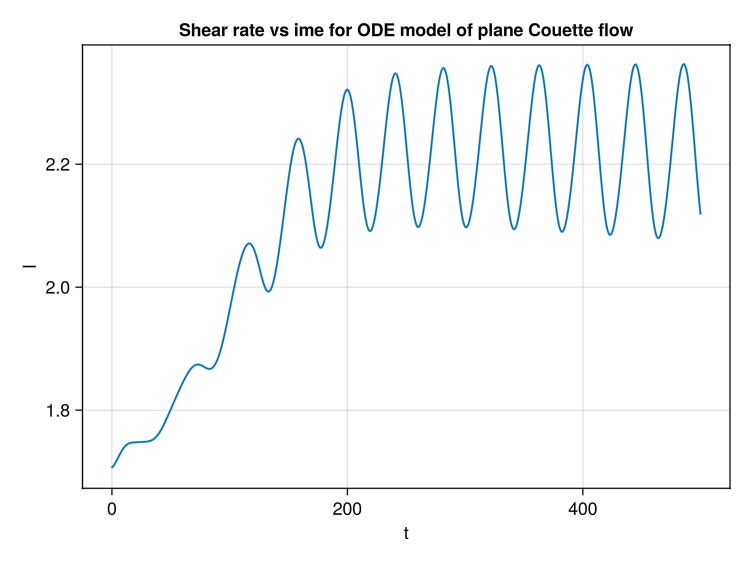

In [176]:
Nsave = 32
Δt = 1/Nsave
Nsteps = 500

#eq1file = "xeq1-Re$(R)-$J-$K-$L.asc"
#xeq1 = myreaddlm(eq1file, cc='%')

t,X = cnab2(xeq1*1.05, model, 200, Δt, Nsave, Nsteps)

shear(x) = dot(model.Ψshear, x) + 1.0

I = [shear(X[:,n]) for n in 1:Nsteps+1]


f = Figure()
ax = Axis(f[1, 1], xlabel = "t", ylabel = "I", title="Shear rate vs ime for ODE model of plane Couette flow")
lines!(t, I)
f

In [16]:
lines(1:21, IDEt[:,1])

UndefVarError: UndefVarError: `IDEt` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### 5. Visualize the initial condition

The `flowfield3d` function takes as arguments

  * `xeq1` a vector of coefficients `x`
  * `model.Ψ` the expansion functions
  * `2pi/α, 2pi/γ` the lengths of the box in x and z: Lx = 2pi/α, Lz = 2pi/γ
  *  24, 33, 24 specification of a 24 x 33 x 24 gird in x,y,z

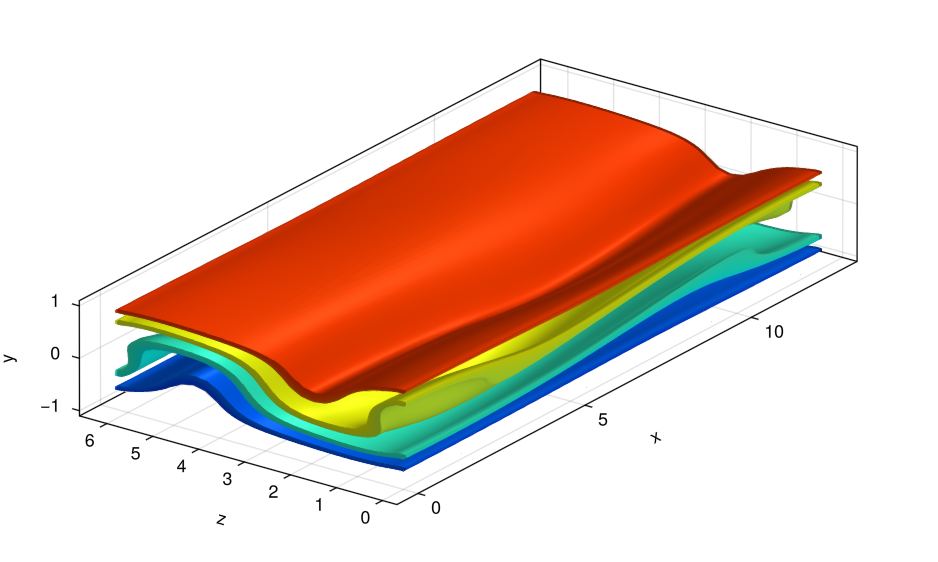

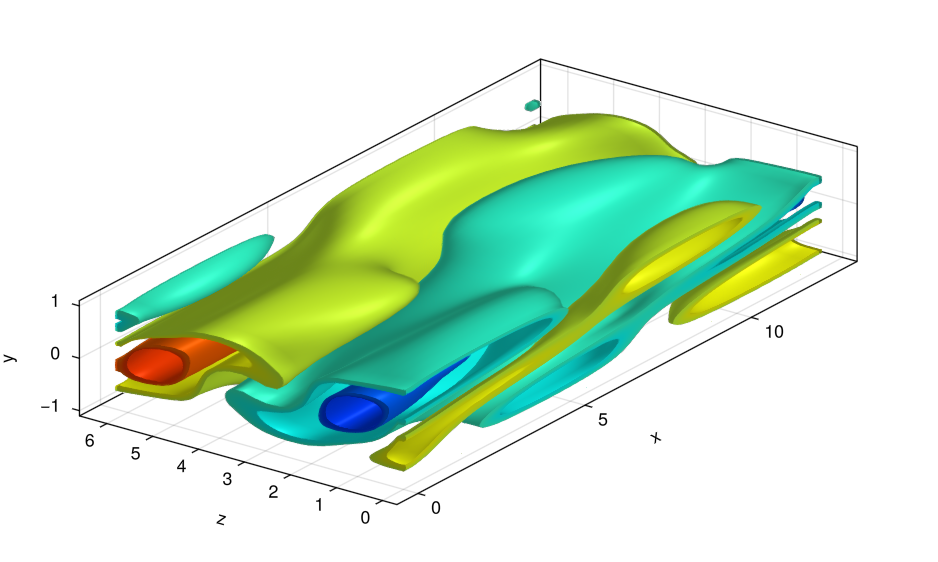

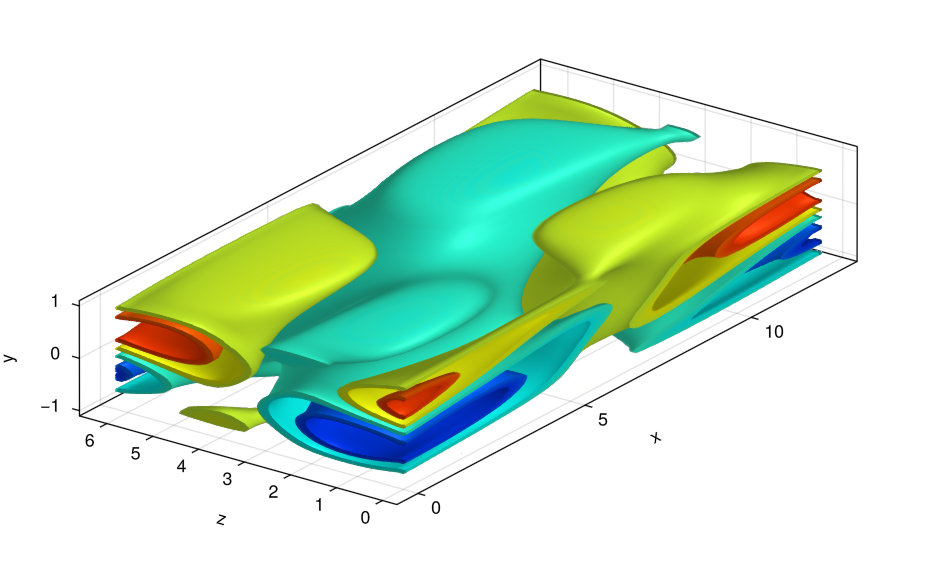

GLMakie.Screen(...)

In [138]:
display(flowfield3d(xeq1, model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, xarrows=0, component=1, arrowcolor=:none, stride=3))
display(flowfield3d(xeq1, model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, xarrows=0, component=2, arrowcolor=:none, stride=3))
display(flowfield3d(xeq1, model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, xarrows=0, component=3, arrowcolor=:none, stride=3))

In [51]:
x

27-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

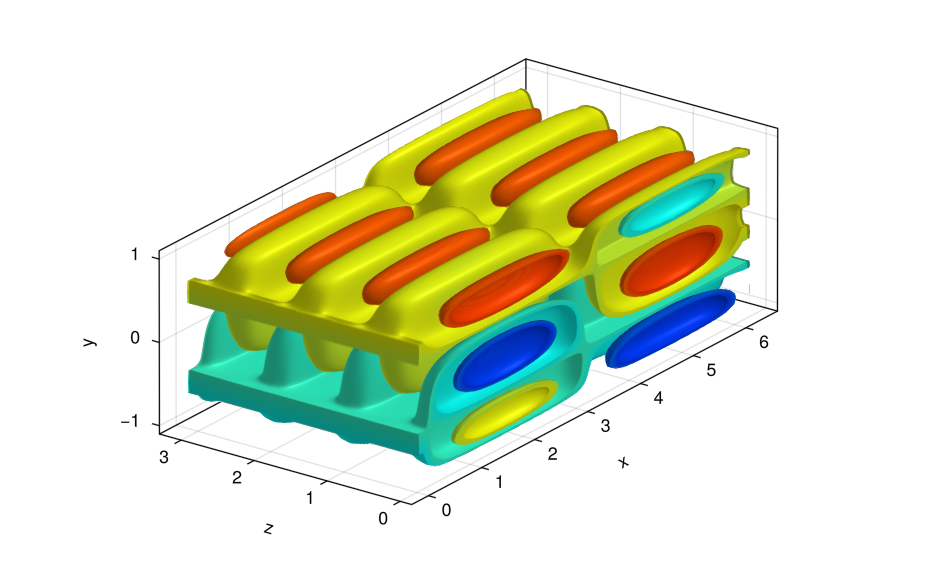

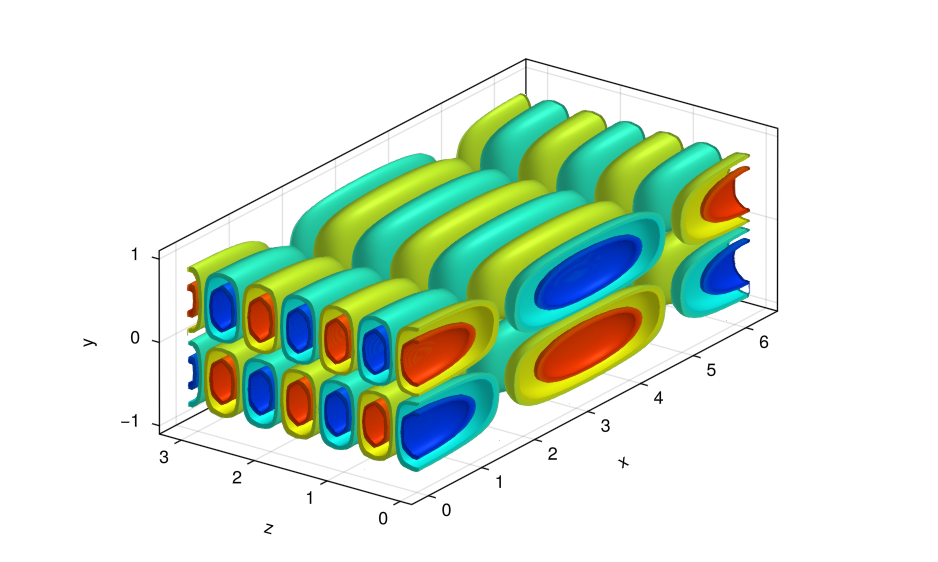

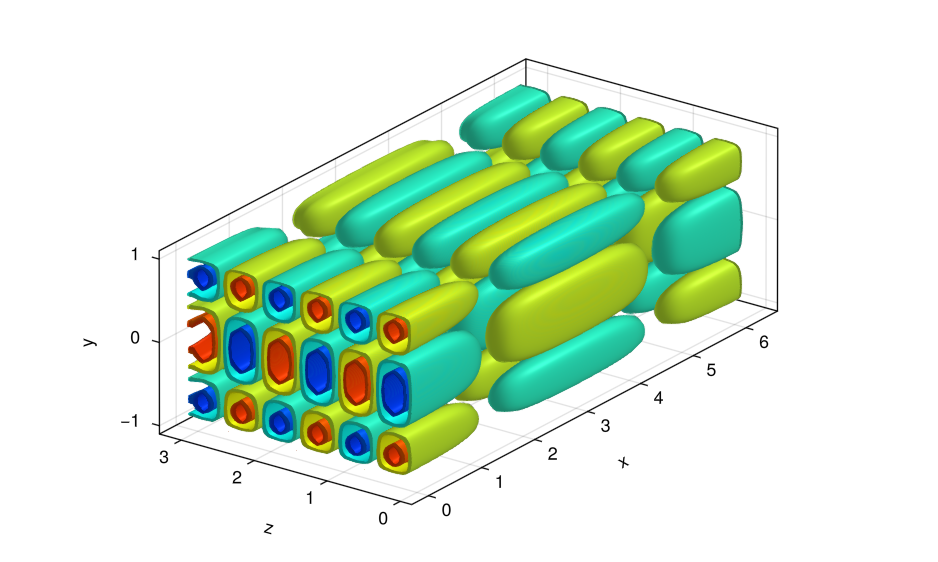

GLMakie.Screen(...)

In [119]:
x = zeros(Nmodes)
x[17] = 1.0
display(flowfield3d(x, model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, xarrows=0, component=1, stride=3))
display(flowfield3d(x, model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, xarrows=0, component=2, stride=3))
display(flowfield3d(x, model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, xarrows=0, component=3, stride=3))

In [121]:
u(x,y,z) = cos(x) * sin(2z) * (y - y^3/3)

u (generic function with 1 method)

### 6. Now save 3d plots of $u(x,t)$ for the first 300 time steps

You can convert these to a movie with PNG -> GIF software.

In [146]:
f = Figure()
ax = Axis(f[1,1])

nframes = 20

n_iterator = 1:nframes

record(f, "orbit1/mp4", n_iterator; framerate=10 do n
        

Base.Meta.ParseError: ParseError:
# Error @ c:\Users\cbalusek\Desktop\CloudAtlas\notebooks\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X24sZmlsZQ==.jl:8:49

record(f, "orbit1/mp4", n_iterator; framerate=10 do n
#                                               └ ── Expected `)` or `,`

In [177]:
try
    mkdir("Makie-Pngs/x$modNum-$α-$γ-$J-$K-$L-x")
    mkdir("Makie-Pngs/x$modNum-$α-$γ-$J-$K-$L-y")
    mkdir("Makie-Pngs/x$modNum-$α-$γ-$J-$K-$L-z")
catch e
    println(e)
end
for n = 1:500
    print("$n ")
    f = flowfield3d(X[:,n], model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, title="t=$n", component=1, xarrows=-1)
    Makie.save("Makie-Pngs/x$modNum-$α-$γ-$J-$K-$L-x/frame-$(n+1000).png", f)
    f = flowfield3d(X[:,n], model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, title="t=$n", component=2, xarrows=-1)
    Makie.save("Makie-Pngs/x$modNum-$α-$γ-$J-$K-$L-y/frame-$(n+1000).png", f)
    f = flowfield3d(X[:,n], model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, title="t=$n", component=3, xarrows=-1)
    Makie.save("Makie-Pngs/x$modNum-$α-$γ-$J-$K-$L-z/frame-$(n+1000).png", f)
end
println()

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274 275 276 277 